## This is a notebook to get parameters from sit tier

In [1]:
from pytools4scarf import dataloader
import matplotlib.pyplot as plt
import numpy as np
import lh5
import awkward as ak

In [3]:
from pathlib import Path
map_dir = Path(
    "/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
)
def map_path(config):
    map_dir ="/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs"
    return map_dir+"/map_calibration_"+config+".yaml"
data_cleaning_path = (
    "/mnt/atlas02/users/leoli/self_metadata/data_cleaning.yaml"
)
map_path('s500ns_mw7')

'/mnt/atlas02/users/leoli/self_metadata/vary_smoothing/maps_vcs/map_calibration_s500ns_mw7.yaml'

## Event tier data and masks.

In [4]:
dfs_evt,lts_evt = {},{}

dfs_evt["r059"], lts_evt["r059"] = dataloader.load_lh5_run(
    ["ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "evt",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
# dfs_evt["r060"], lts_evt["r060"] = dataloader.load_lh5_run(
#     ["ch002/evt"],
#     "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
#     data_cleaning_path,
#     "evt",
#     "sp01",
#     "p05",
#     "r060",
#     "phy",
#     ["ch002"],
# )
# dfs_evt["r038"], lts_evt["r038"] = dataloader.load_lh5_run(
#     ["ch002/evt"],
#     "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
#     data_cleaning_path,
#     "evt",
#     "sp01",
#     "p00",
#     "r038",
#     "phy",
#     ["ch002"],
# )


In [5]:
# masks for physical events, which are defined as events with A_max_mw_o_E_fix_Classifier < 3, Iasy < 0, and not pulser or muon events, and valid waveform.
r059_masks = (
    (dfs_evt['r059']['ch002'].A_max_mw_o_E_fix_Classifier<3)
    & (dfs_evt['r059']['ch002'].Iasy<0)
    & ~(dfs_evt['r059']['ch002'].is_pulser)            
    & ~(dfs_evt['r059']['ch002'].is_muon)
    & (dfs_evt['r059']['ch002'].is_valid_waveform)
)
# r038_masks = (
#     (dfs_evt['r038']['ch002'].A_max_mw_o_E_fix_Classifier<3)
# & (dfs_evt['r038']['ch002'].Iasy<0)
# & ~(dfs_evt['r038']['ch002'].is_pulser)            
# & ~(dfs_evt['r038']['ch002'].is_muon)
# & (dfs_evt['r038']['ch002'].is_valid_waveform)
# )
# r060_masks = ((dfs_evt['r060']['ch002'].A_max_mw_o_E_fix_Classifier<3)
# & (dfs_evt['r060']['ch002'].Iasy<0)
# & ~(dfs_evt['r060']['ch002'].is_pulser)            
# & ~(dfs_evt['r060']['ch002'].is_muon)
# & (dfs_evt['r060']['ch002'].is_valid_waveform)
# )
# for the HE events, we want to select only the muon events, and exclude pulser events.
r059_he_masks = (
~(dfs_evt['r059']['ch002'].is_pulser)            
& ~(dfs_evt['r059']['ch002'].is_muon)
& (dfs_evt['r059']['ch002'].A_max_mw_o_E_fix_Classifier<3)
& (dfs_evt['r059']['ch002'].Iasy<0)
& (dfs_evt['r059']['ch002'].is_valid_waveform)
)
# r038_he_masks = (
# ~(dfs_evt['r038']['ch002'].is_pulser)            
# & ~(dfs_evt['r038']['ch002'].is_muon)
# & (dfs_evt['r038']['ch002'].A_max_mw_o_E_fix_Classifier<3)
# & (dfs_evt['r038']['ch002'].Iasy<0)
# & (dfs_evt['r038']['ch002'].is_valid_waveform)
# )
# r060_he_masks = (
# ~(dfs_evt['r060']['ch002'].is_pulser)            
# & ~(dfs_evt['r060']['ch002'].is_muon)
# & (dfs_evt['r060']['ch002'].A_max_mw_o_E_fix_Classifier<3)
# & (dfs_evt['r060']['ch002'].Iasy<0)
# & (dfs_evt['r060']['ch002'].is_valid_waveform)
# )

r059_argon_mask = (dfs_evt['r059']['ch002'].is_lar_vetoed)
# r060_argon_mask = (dfs_evt['r060']['ch002'].is_lar_vetoed)

## sit tier analysis 

### Combined Cut


In [6]:
# candidate = best_candidates[0]
candidate ='s500ns_mw3'

dfs_sit_candidate, lts_sit_candidate = {}, {}
# dfs_sit_candidate["r038"], lts_sit_candidate["r038"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(candidate),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p00",
#     "r038",
#     "phy",
#     ["ch002"],
# )
dfs_sit_candidate["r059"], lts_sit_candidate["r059"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
# dfs_sit_candidate["r060"], lts_sit_candidate["r060"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(candidate),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p05",
#     "r060",
#     "phy",
#     ["ch002"],
# )

In [7]:
# candidate = best_candidates[0]
candidate_2 ='s40ns_mw7'

dfs_sit_candidate_2, lts_sit_candidate_2 = {}, {}
# dfs_sit_candidate_2["r038"], lts_sit_candidate_2["r038"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(candidate_2),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p00",
#     "r038",
#     "phy",
#     ["ch002"],
# )
dfs_sit_candidate_2["r059"], lts_sit_candidate_2["r059"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(candidate_2),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
# dfs_sit_candidate_2["r060"], lts_sit_candidate_2["r060"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(candidate_2),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p05",
#     "r060",
#     "phy",
#     ["ch002"],
# )

In [8]:
gamma_r059 = ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
         ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
         ((dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r059']['ch002'].trapEftp_fix_cal<2424.3+5))
# gamma_r038 = ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
#          ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
#          ((dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r038']['ch002'].trapEftp_fix_cal<2424.3+5))
# gamma_r060 = ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>1837.2-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<1837.2+5)) | \
#          ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>1920.8-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<1920.8+5)) | \
#          ((dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal>2424.3-5) & (dfs_sit_candidate['r060']['ch002'].trapEftp_fix_cal<2424.3+5))
# candidate_roi_mask_r038 = (
# (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal >= 1839)
# & (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal <= 2239)
# & ~(gamma_r038) 
# )
candidate_roi_mask_r059 = (
(dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal >= 1839)
& (dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal <= 2239)
& ~(gamma_r059)
)
# candidate_roi_mask_r060 = (
# (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal >= 1839)
# & (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal <= 2239)
# & ~(gamma_r060)
# )
# candidate_he_mask_r038 = (
# (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal >= 6000)
# & (dfs_sit_candidate["r038"]['ch002'].trapEftp_fix_cal <= 10000)
# )
candidate_he_mask_r059 = (
(dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal >= 6000)
& (dfs_sit_candidate["r059"]['ch002'].trapEftp_fix_cal <= 10000)
)
# candidate_he_mask_r060 = (
# (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal >= 6000)
# & (dfs_sit_candidate["r060"]['ch002'].trapEftp_fix_cal <= 10000)
# )


### scarf default

In [9]:
default='s100ns_mw5'

dfs_sit_default, lts_sit_default = {}, {}
# dfs_sit_default["r038"], lts_sit_default["r038"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(default),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p00",
#     "r038",
#     "phy",
#     ["ch002"],
# )
dfs_sit_default["r059"], lts_sit_default["r059"] = dataloader.load_lh5_run(
    ["ch002/hit"],
    map_path(default),
    data_cleaning_path,
    "sit",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
# dfs_sit_default["r060"], lts_sit_default["r060"] = dataloader.load_lh5_run(
#     ["ch002/hit"],
#     map_path(default),
#     data_cleaning_path,
#     "sit",
#     "sp01",
#     "p05",
#     "r060",
#     "phy",
#     ["ch002"],
# )

In [2]:
selection_r059 = (
    candidate_roi_mask_r059 # ROI mask with gamma line masks
    & r059_masks # not alpha, not pulser, not muon, is valid wf
    & ~r059_argon_mask
    & (
        ~(
            (dfs_sit_candidate["r059"]["ch002"].A_max_mw_o_E_fix_Low_Cut)
            # &(dfs_sit_candidate["r059"]["ch002"].A_max_mw_o_E_fix_Classifier<-3)
            &(dfs_sit_candidate_2["r059"]["ch002"].A_max_mw_o_E_fix_Low_Cut)
        )
        & (dfs_sit_default["r059"]["ch002"].A_max_mw_o_E_fix_Low_Cut)
    )
)

default_sse_mask_r059 = (
(dfs_sit_default["r059"]['ch002'].trapEftp_fix_cal >=1592.5-5 )
& (dfs_sit_default["r059"]['ch002'].trapEftp_fix_cal <= 1592.5+5)
)

selection_r059_sse= (
    default_sse_mask_r059 # DEP peak
    & r059_masks # not alpha, not pulser, not muon, is valid wf
    & ( (dfs_sit_default["r059"]["ch002"].A_max_mw_o_E_fix_Classifier>-0.2)
        & (dfs_sit_default["r059"]["ch002"].A_max_mw_o_E_fix_Classifier<0.2)
    )
)
selection_r059 = np.asarray(selection_r059)
selection_r059_sse = np.asarray(selection_r059_sse)
print(np.sum(selection_r059))
print(np.sum(selection_r059_sse))
    

NameError: name 'candidate_roi_mask_r059' is not defined

## plots

In [11]:
# argon_mask = ak.concatenate([r059_argon_mask,r060_argon_mask])

In [1]:
pathlist_raw={};lts_raw={}
pathlist_dsp={};lts_dsp={}
pathlist_raw["r059"], lts_raw["r059"] = dataloader.load_lh5_run_filepath(
    ["ch002/raw"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    data_cleaning_path,
    "raw",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch002"],
)
# pathlist_dsp["r059"], lts_dsp["r059"] = dataloader.load_lh5_run_filepath(
#     ["ch002/dsp"],
#     "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
#     data_cleaning_path,
#     "dsp",
#     "sp01",
#     "p05",
#     "r059",
#     "phy",
#     ["ch002"],
# )

NameError: name 'dataloader' is not defined

In [13]:
# np.sum(mask)
# selection_r059 = masks["r059"]

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from pytools4scarf.utils import minmax, load_yaml
import dspeed
import tol_colors as tc

dsp_config = load_yaml("/mnt/atlas01/users/vogl/scarf/sp01/metadata/dsp/ged_dsp_conf.yaml")
dsp_database = load_yaml("/mnt/atlas01/users/vogl/scarf/sp01/metadata/dsp/dsp_database_general.yaml")

dsp_config["outputs"].extend(["wf_blsub", "wf_pz", "wf_single_pz", "wf_blsub_win", "wf_pz_win", "wf_single_pz_win",
                              "wf_etrap", "wf_etrap_fix", "wf_atrap_win", "tp_start",
                              "curr_win", "curr_up_win", "curr_av_win", "wf_tri", "wf_mwavg_win", "wf_mwavg_up_win", "wf_mwavg_up_curr_win",
                              "Iasy_threshold"
                              ])
dsp_config["processors"]["wf_single_pz"] = {
    "function": "pole_zero",
    "module": "dspeed.processors",
    "args": ["wf_blsub", "db.pz.tau1", "wf_single_pz"],
    "unit": "ADC",
}
dsp_config["processors"]["wf_single_pz_win"] = {
    "function": "pole_zero",
    "module": "dspeed.processors",
    "args": ["wf_blsub_win", "db.pz.tau1", "wf_single_pz_win"],
    "unit": "ADC",
}


In [ ]:
masked_data_raw_sse = lh5.read('ch002/raw',pathlist_raw['r059'],idx=selection_r059_sse)
masked_data_raw = lh5.read('ch002/raw',pathlist_raw['r059'],idx=selection_r059)


In [ ]:
proc_df_sse = dspeed.build_dsp(
    raw_in=masked_data_raw_sse,
    lh5_tables="ch002",
    dsp_config=dsp_config,
    database=dsp_database,
    n_entries=100
)
proc_tb_sse = proc_df_sse["ch002"]

In [ ]:
proc_df = dspeed.build_dsp(
    raw_in=masked_data_raw,
    lh5_tables="ch002",
    dsp_config=dsp_config,
    database=dsp_database,
    n_entries=100
)
proc_tb = proc_df["ch002"]

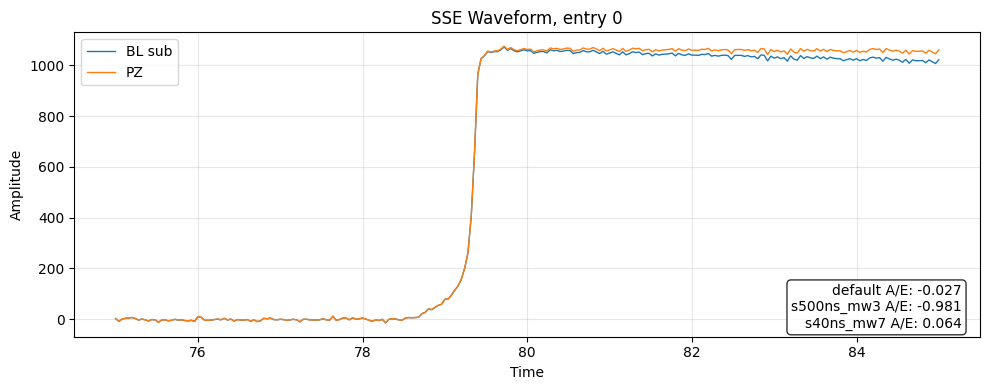

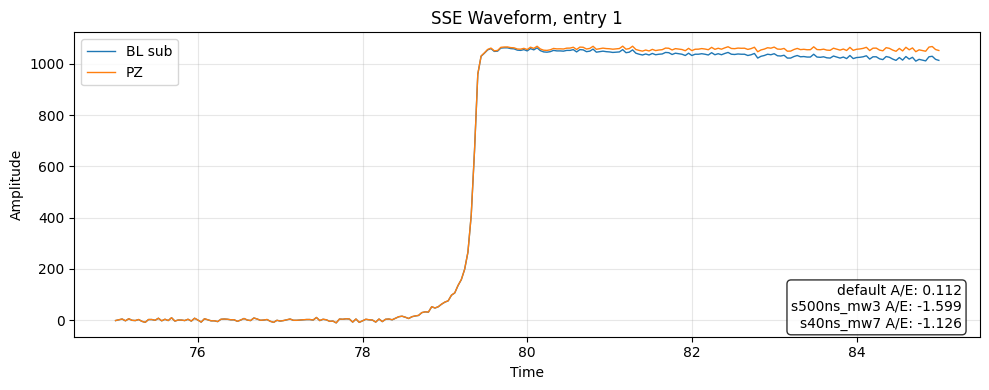

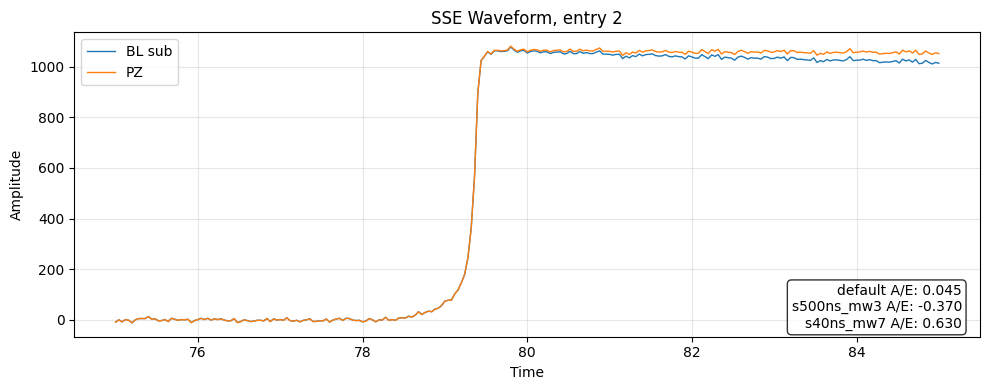

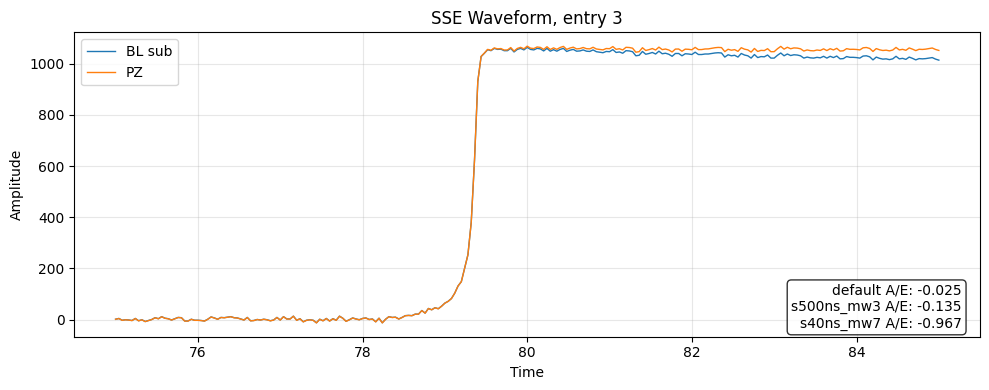

IndexError: index 4 is out of bounds for axis 0 with size 4

In [66]:
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
ts_presummed_values = np.arange(0, 160, 0.04)

# windowed wf
time_mask = (ts_presummed_values >= 75) & (ts_presummed_values <= 85)

for entry in range(50):

    # full waveforms
    values_full = ak.to_numpy(proc_tb_sse["wf_blsub.values"][entry])
    values_pz_full = ak.to_numpy(proc_tb_sse["wf_pz.values"][entry])

    # select only 75–85
    values = values_full[time_mask]
    values_pz = values_pz_full[time_mask]

    # corresponding time axis
    time = ts_presummed_values[time_mask]

    aoe = np.asarray(
        dfs_sit_default["r059"]["ch002"][selection_r059_sse]
        .A_max_mw_o_E_fix_Classifier
    )[entry]

    aoe_candidate = np.asarray(
        dfs_sit_candidate["r059"]["ch002"][selection_r059_sse]
        .A_max_mw_o_E_fix_Classifier
    )[entry]

    aoe_candidate_2 = np.asarray(
        dfs_sit_candidate_2["r059"]["ch002"][selection_r059_sse]
        .A_max_mw_o_E_fix_Classifier
    )[entry]

    text = (
        f"default aoe: {aoe:.3f}\n"
        f"{candidate} aoe: {aoe_candidate:.3f}\n"
        f"{candidate_2} aoe: {aoe_candidate_2:.3f}"
    )

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(time, values, lw=1, label="BL sub")
    ax.plot(time, values_pz, lw=1, label="PZ")

    text = (
        f"default A/E: {aoe:.3f}\n"
        f"{candidate} A/E: {aoe_candidate:.3f}\n"
        f"{candidate_2} A/E: {aoe_candidate_2:.3f}"
    )

    ax.text(
        0.98, 0.02,
        text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
        )
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"SSE Waveform, entry {entry}")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

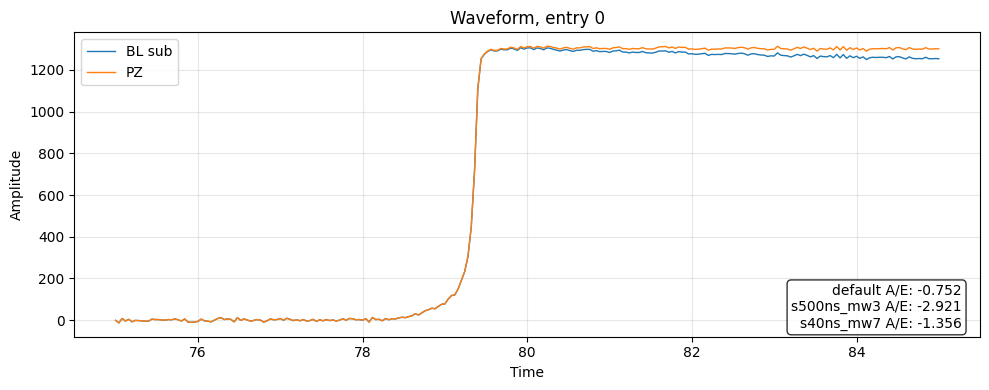

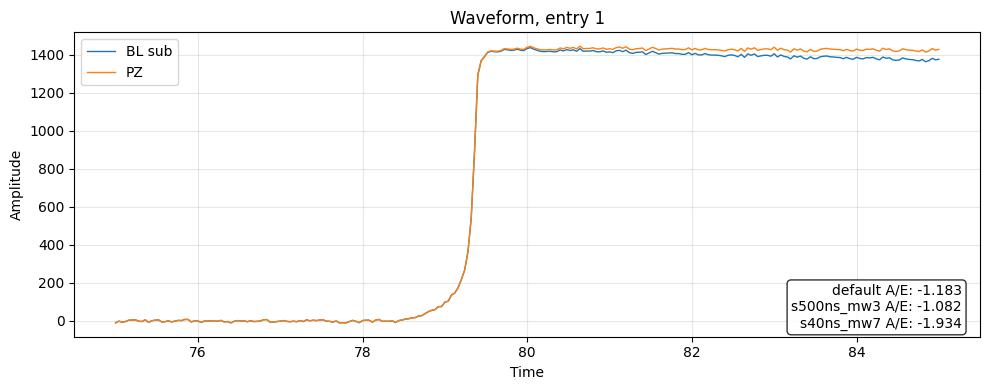

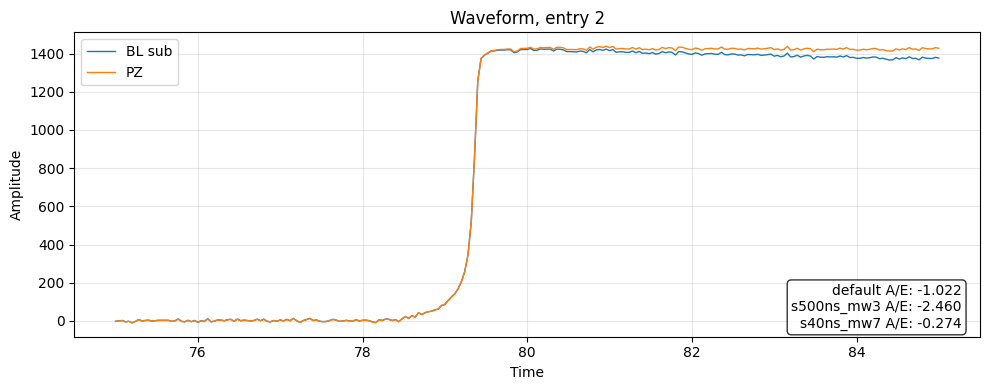

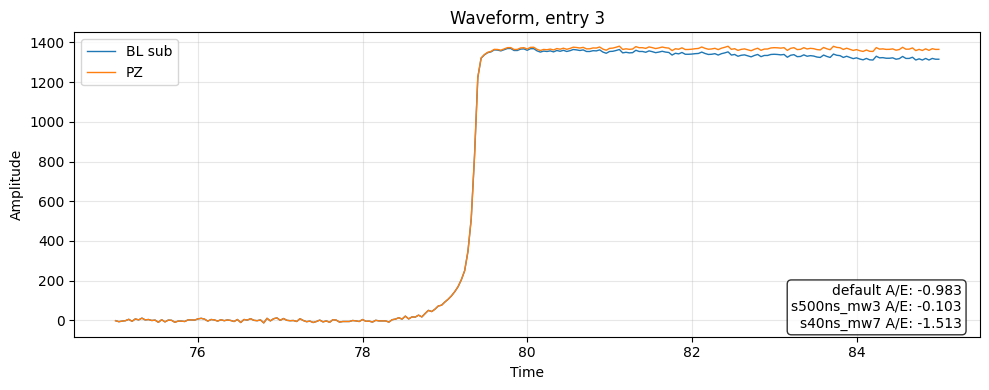

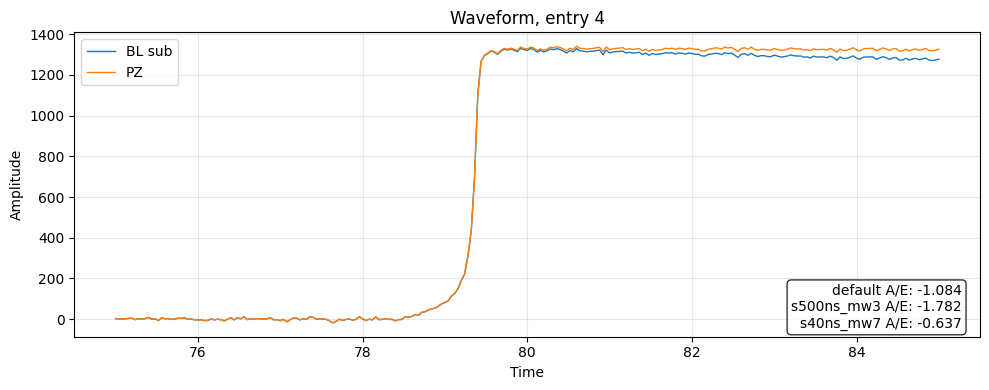

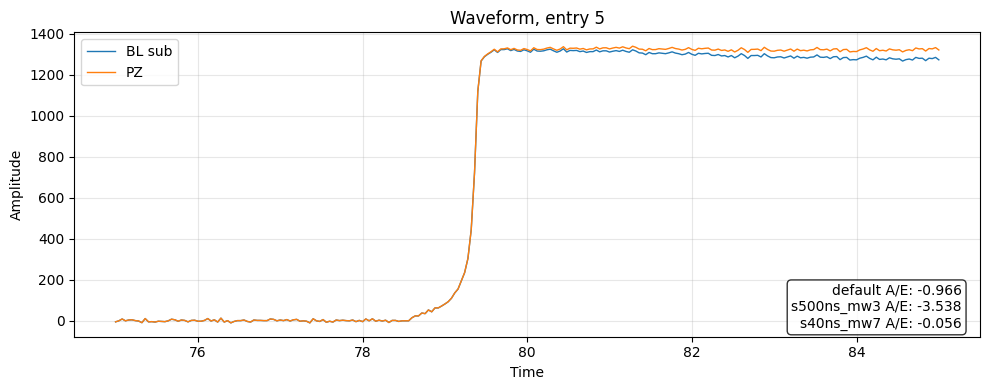

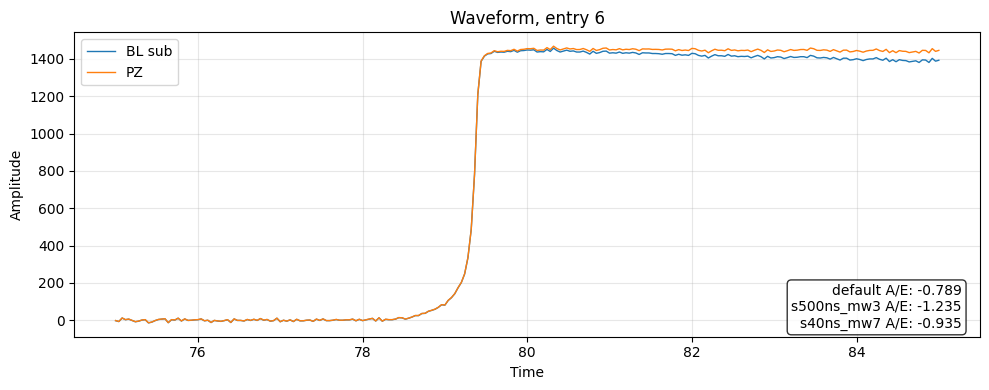

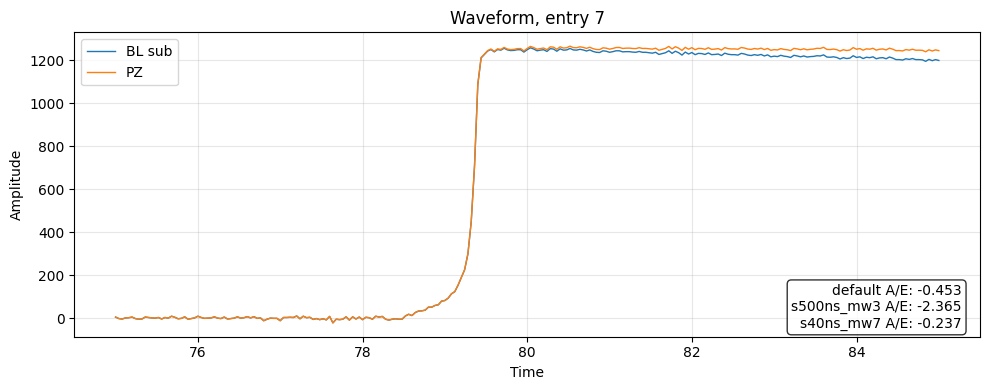

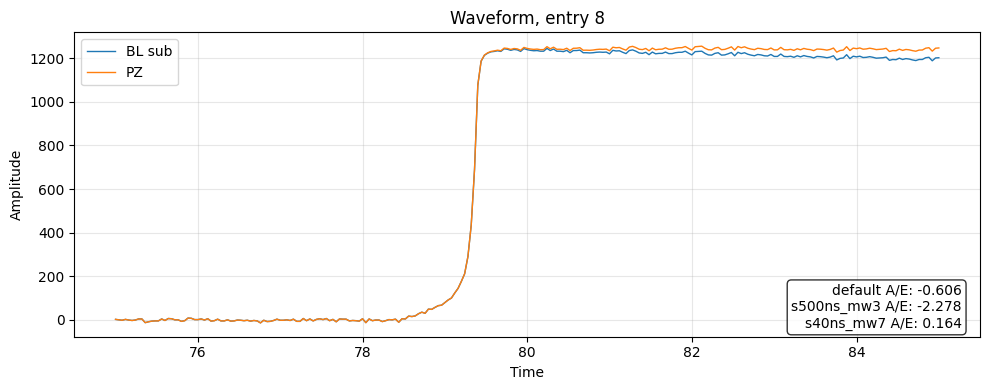

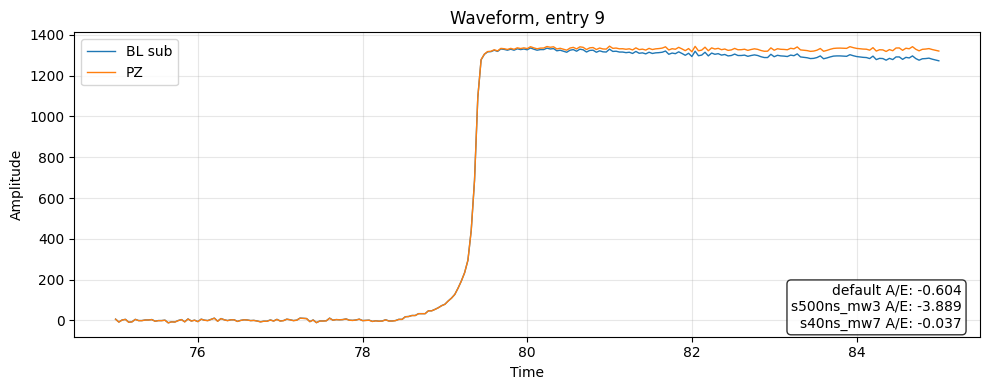

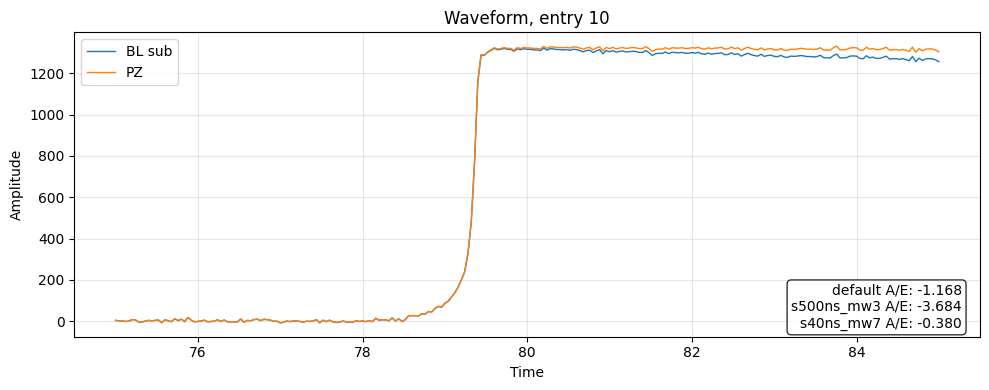

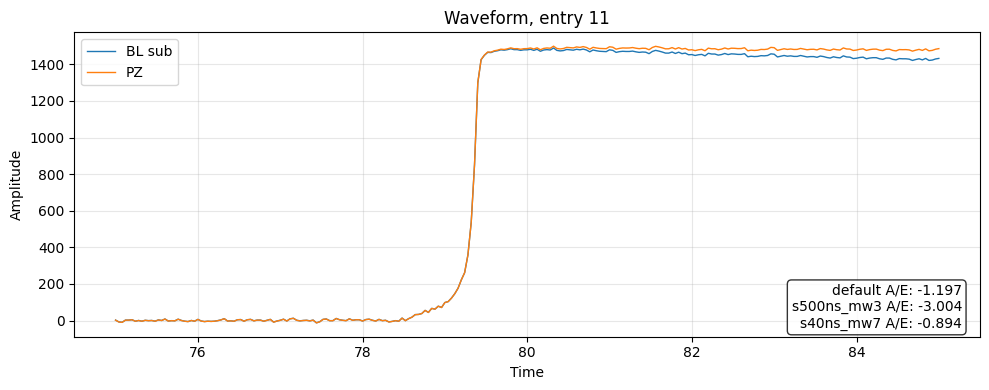

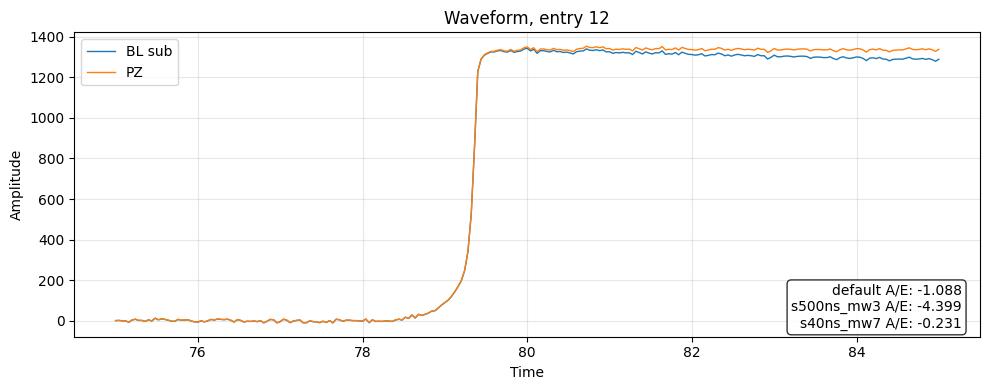

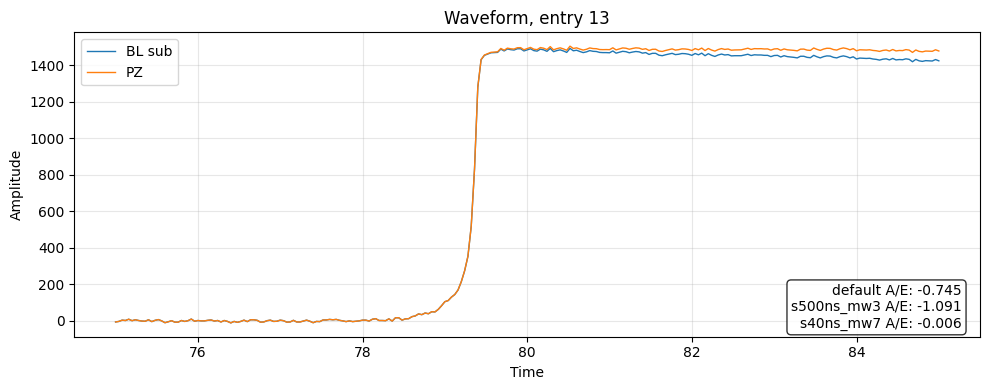

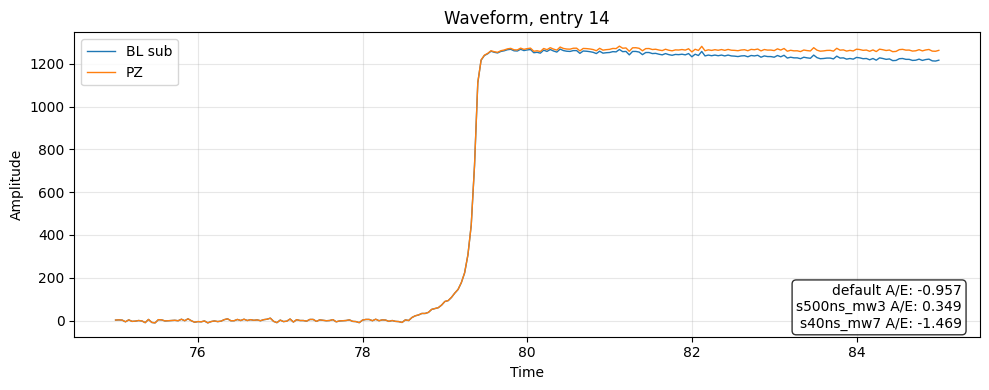

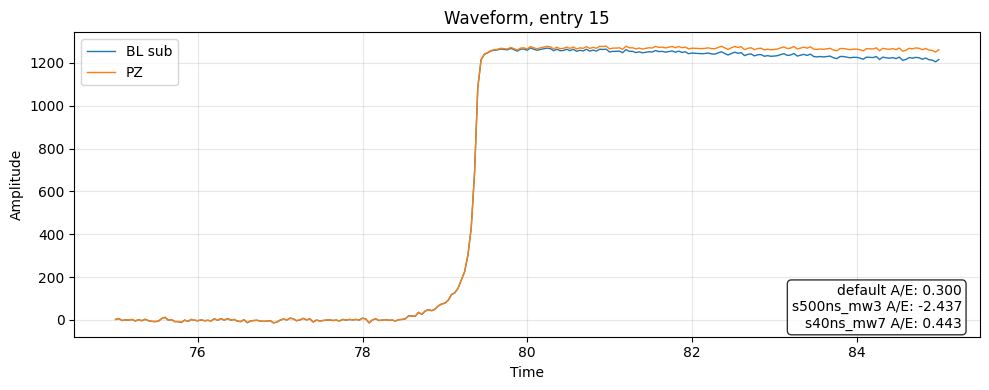

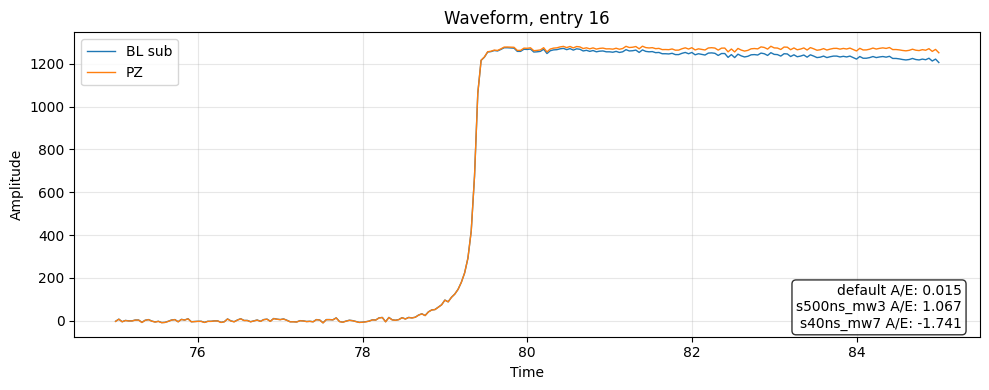

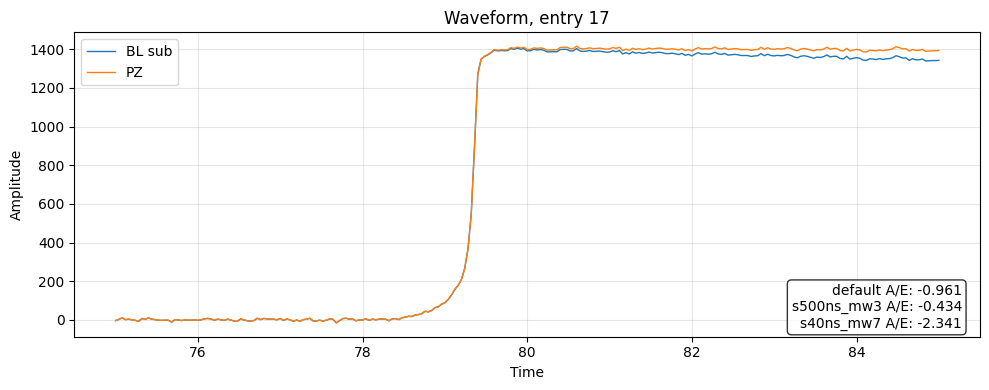

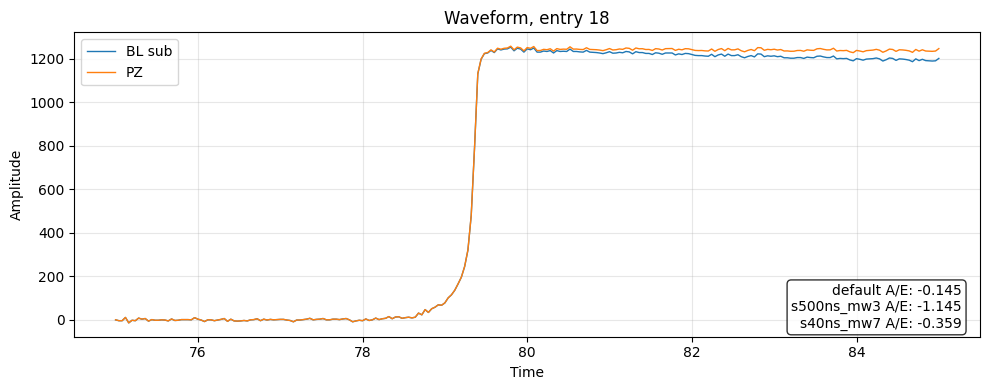

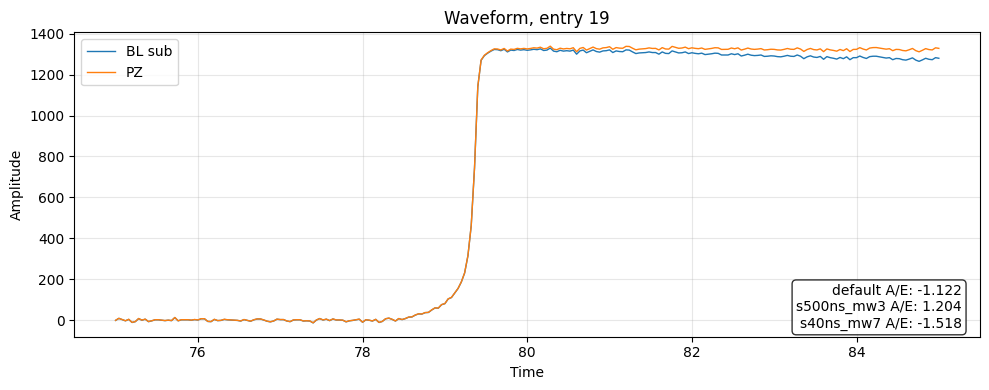

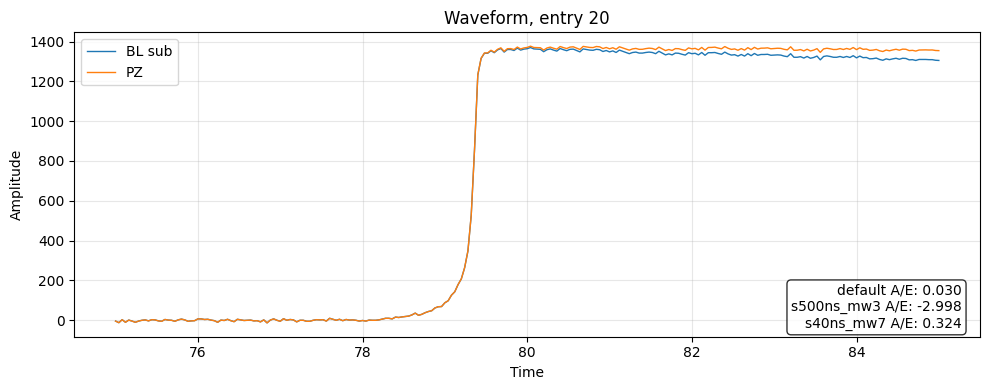

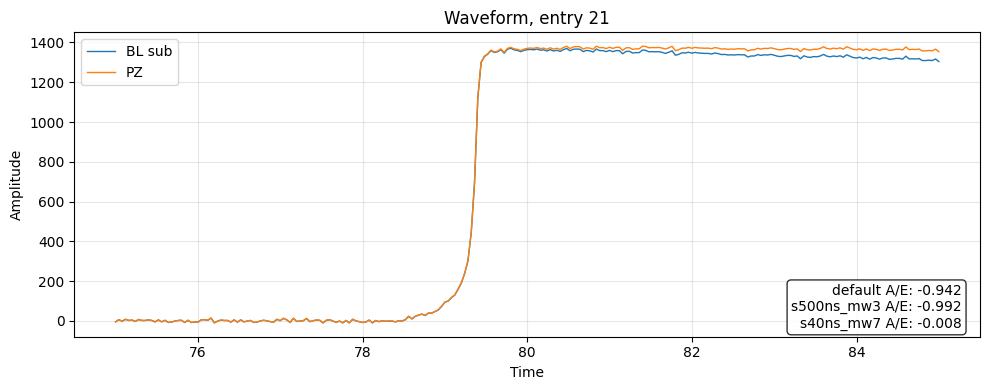

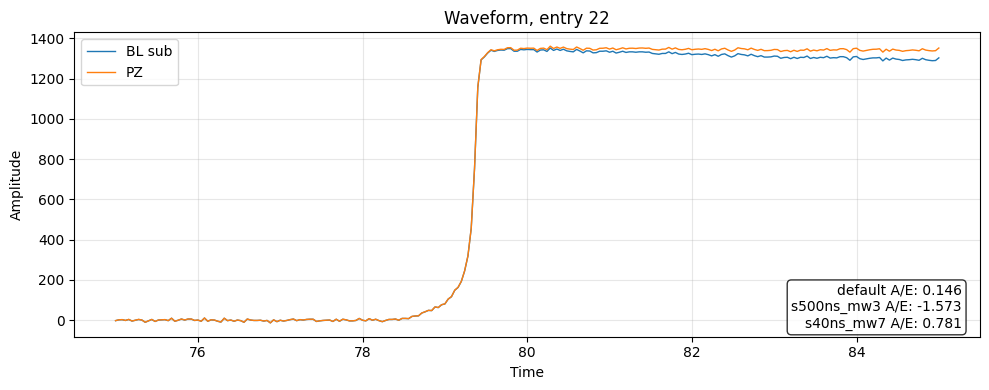

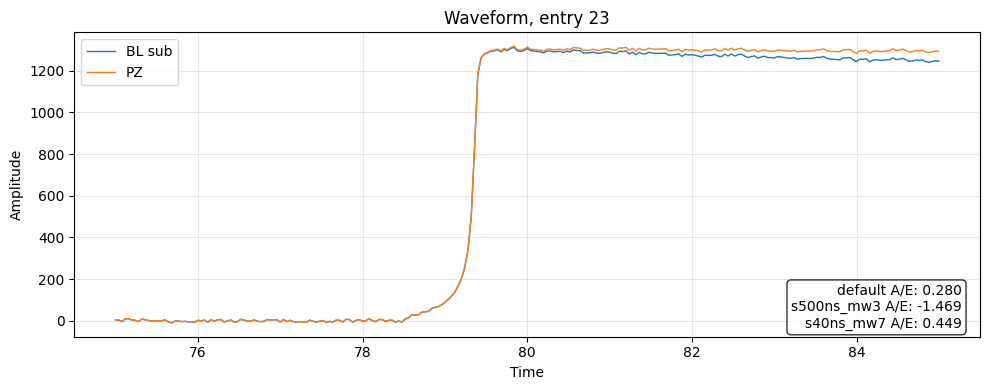

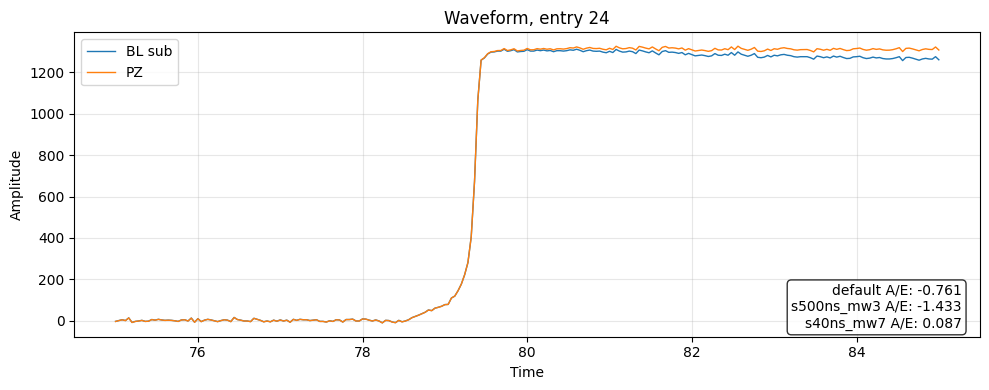

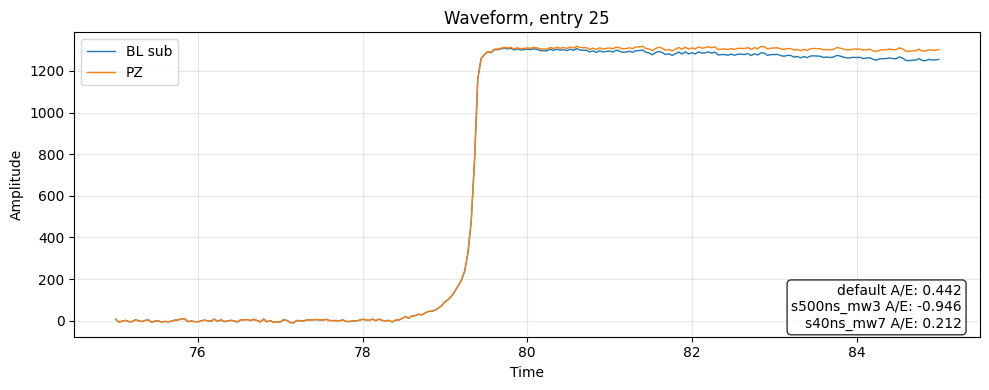

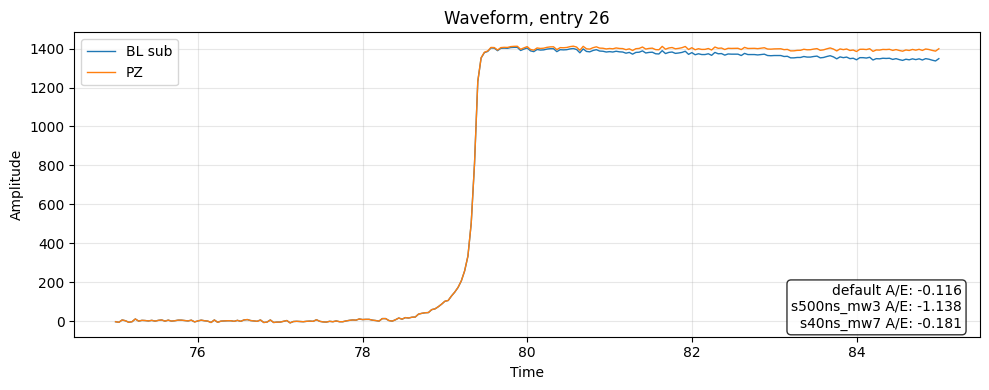

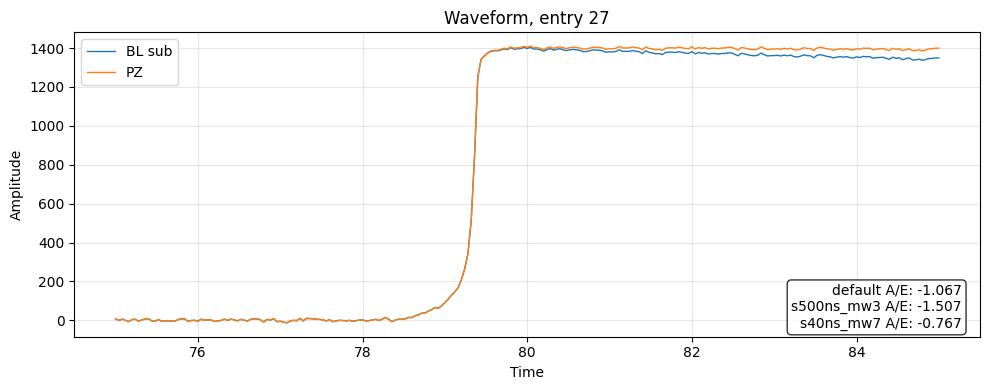

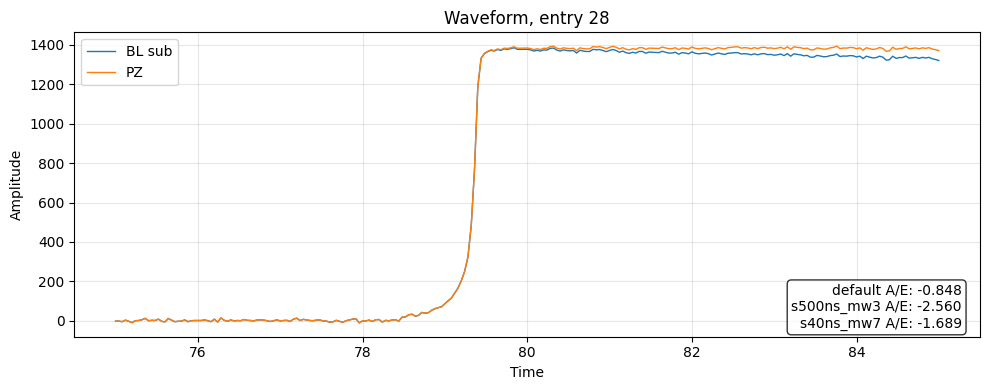

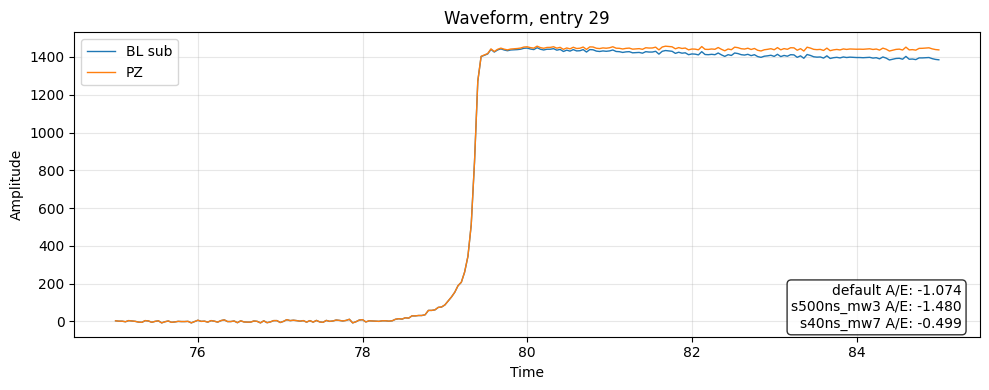

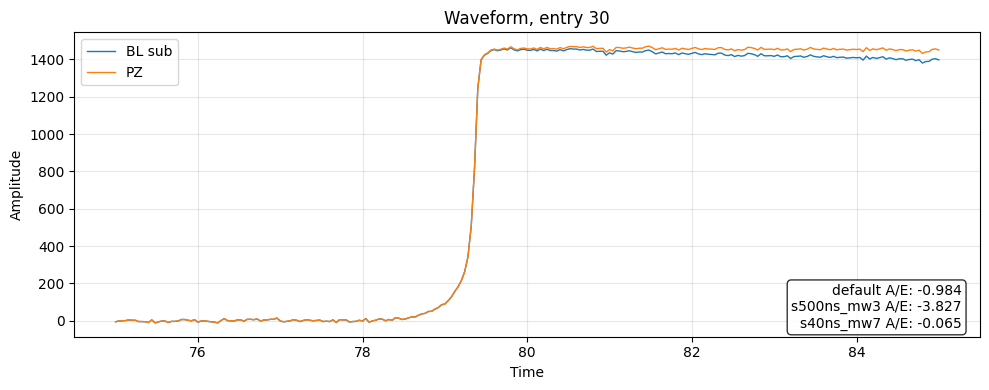

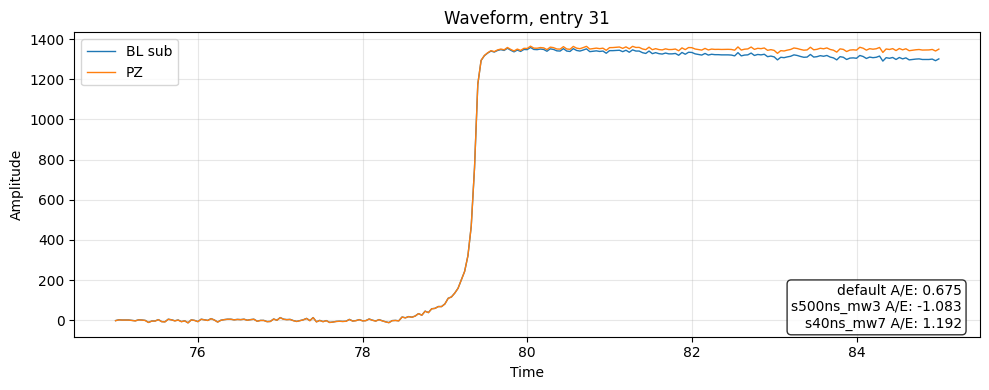

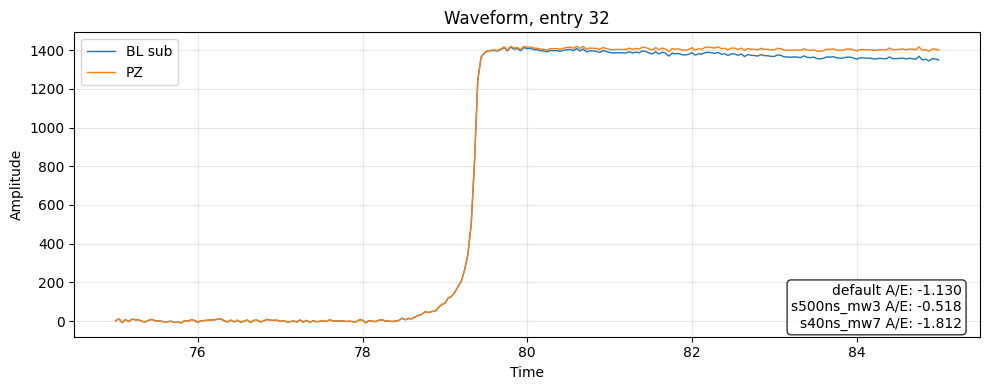

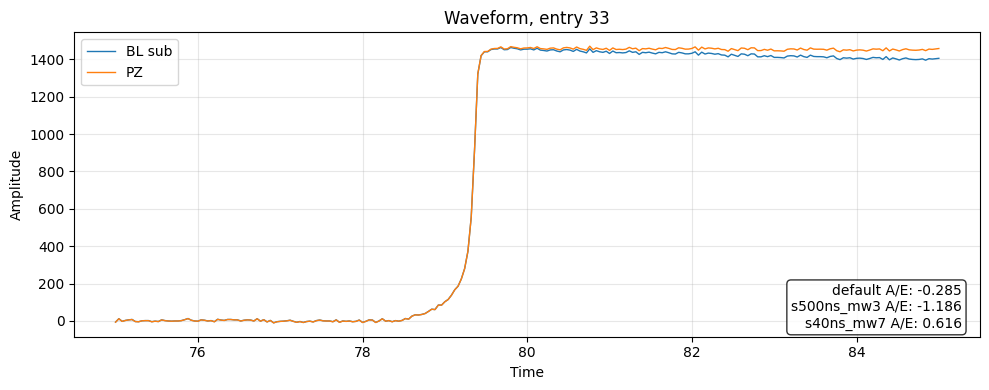

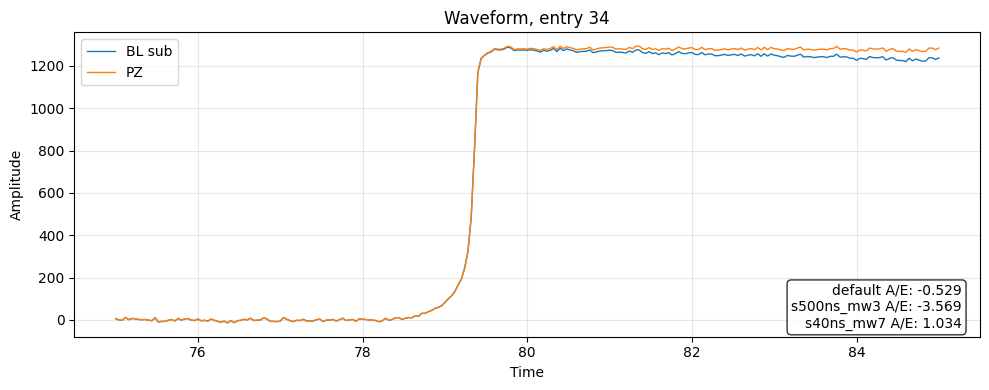

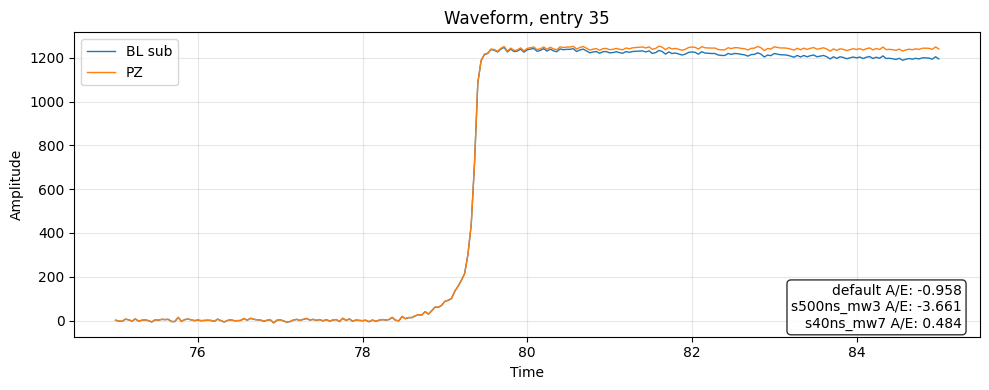

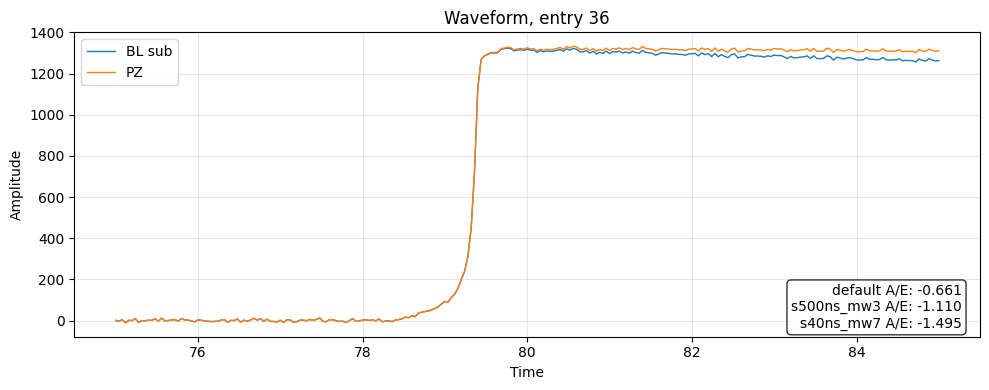

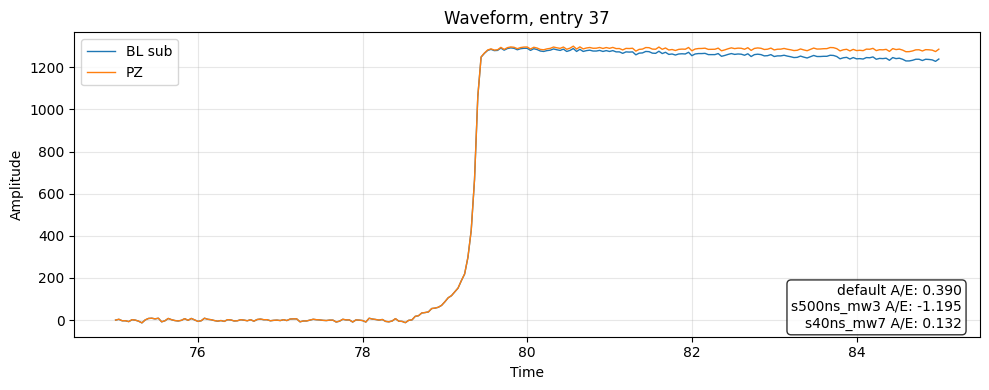

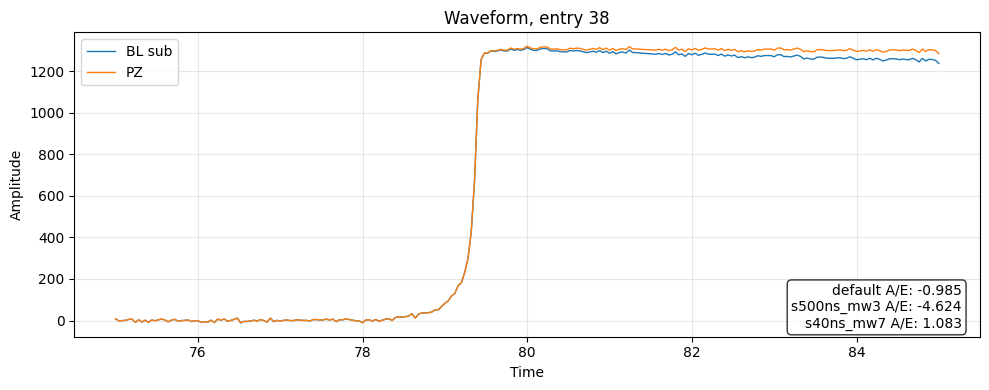

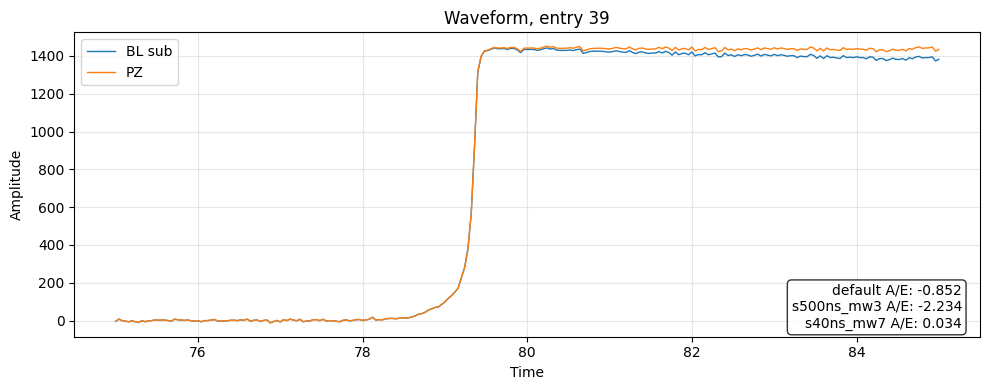

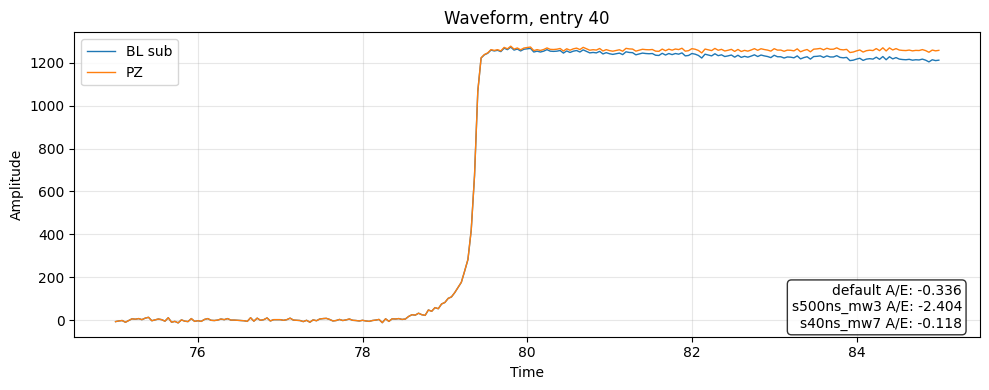

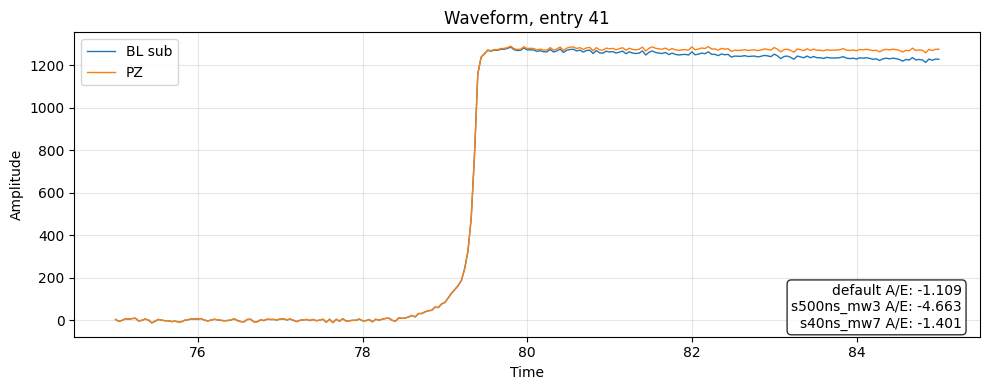

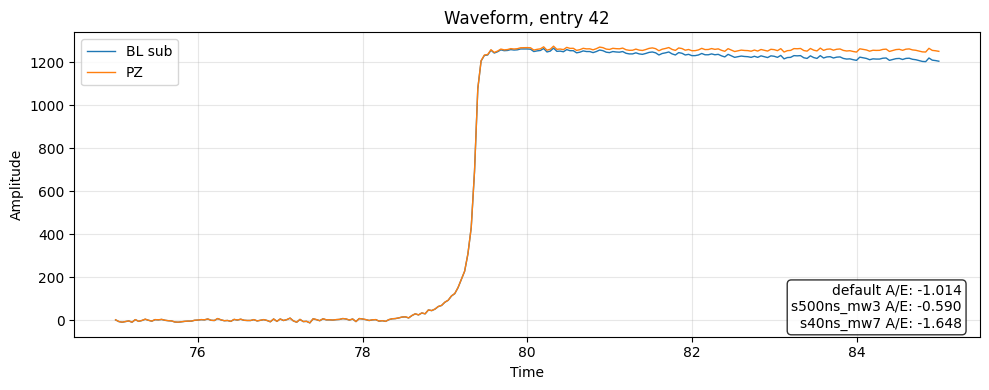

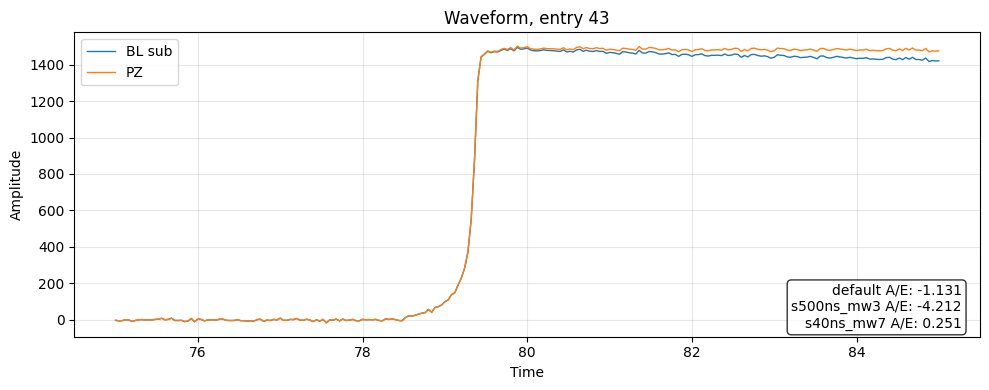

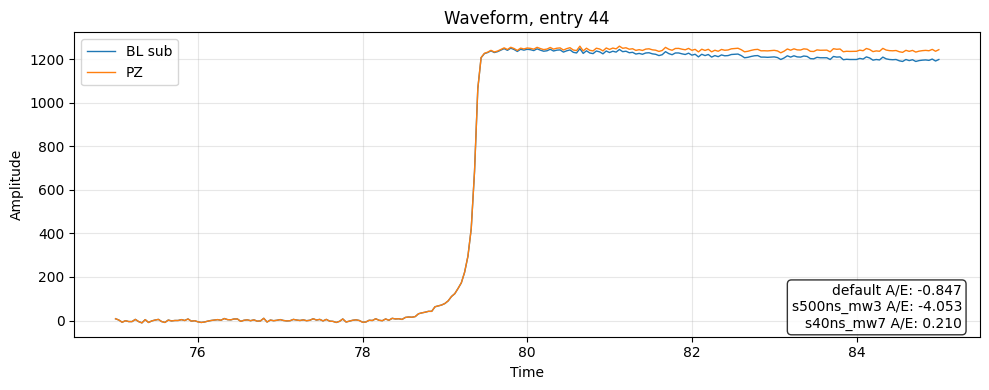

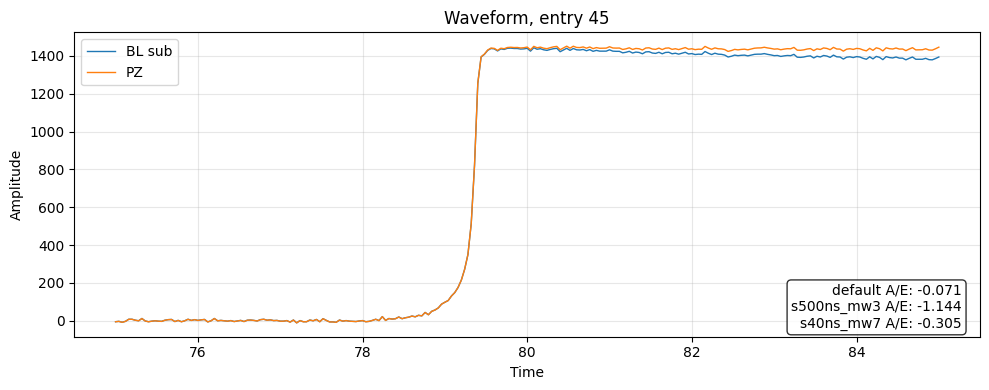

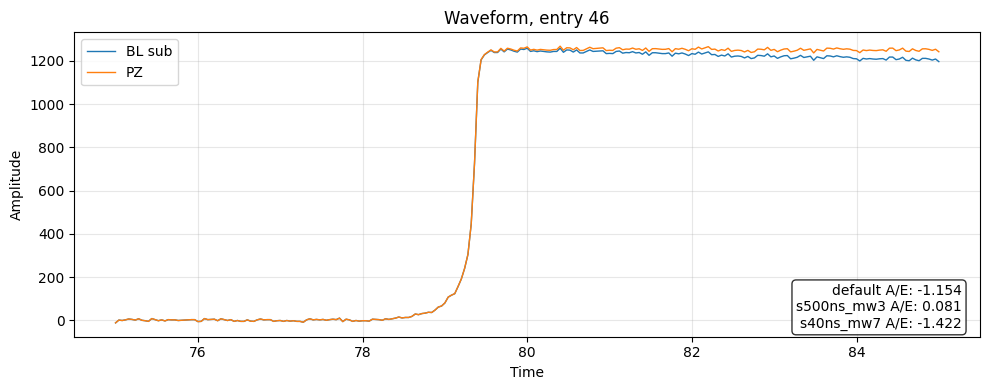

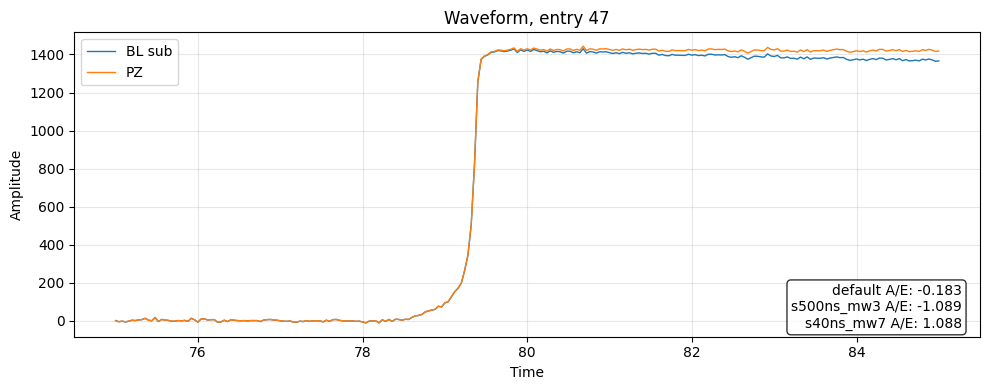

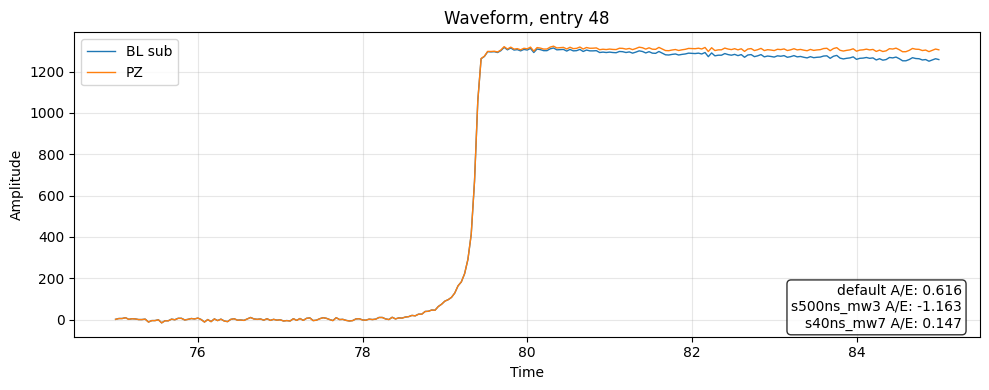

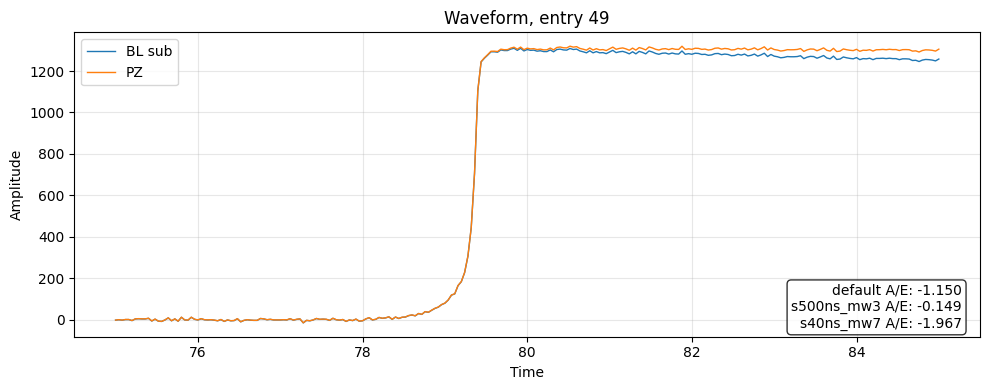

In [67]:
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
ts_presummed_values = np.arange(0, 160, 0.04)

# windowed wf
time_mask = (ts_presummed_values >= 75) & (ts_presummed_values <= 85)

for entry in range(50):

    # full waveforms
    values_full = ak.to_numpy(proc_tb["wf_blsub.values"][entry])
    values_pz_full = ak.to_numpy(proc_tb["wf_pz.values"][entry])

    # select only 75–85
    values = values_full[time_mask]
    values_pz = values_pz_full[time_mask]

    # corresponding time axis
    time = ts_presummed_values[time_mask]

    aoe = np.asarray(
        dfs_sit_default["r059"]["ch002"][selection_r059]
        .A_max_mw_o_E_fix_Classifier
    )[entry]

    aoe_candidate = np.asarray(
        dfs_sit_candidate["r059"]["ch002"][selection_r059]
        .A_max_mw_o_E_fix_Classifier
    )[entry]

    aoe_candidate_2 = np.asarray(
        dfs_sit_candidate_2["r059"]["ch002"][selection_r059]
        .A_max_mw_o_E_fix_Classifier
    )[entry]

    text = (
        f"default aoe: {aoe:.3f}\n"
        f"{candidate} aoe: {aoe_candidate:.3f}\n"
        f"{candidate_2} aoe: {aoe_candidate_2:.3f}"
    )

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(time, values, lw=1, label="BL sub")
    ax.plot(time, values_pz, lw=1, label="PZ")

    text = (
        f"default A/E: {aoe:.3f}\n"
        f"{candidate} A/E: {aoe_candidate:.3f}\n"
        f"{candidate_2} A/E: {aoe_candidate_2:.3f}"
    )

    ax.text(
        0.98, 0.02,
        text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
        )
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Waveform, entry {entry}")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()